In [ ]:
#Importing some files

import os 
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Address of Dataset
train_base = r"D:\Visual Studio Code\ML\LungCancerImg\Data\train"

(258, 437, 4)


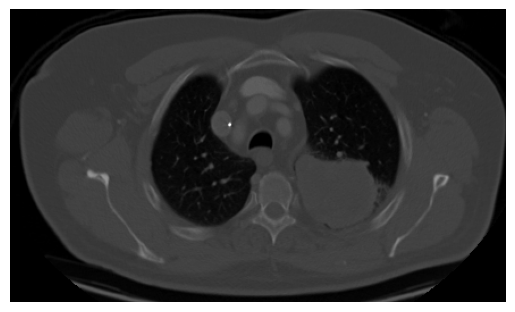

In [ ]:
#Displaying one Image
path = r'D:\Visual Studio Code\ML\LungCancerImg\Data\train\large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa\000003 (3).png'

#Reading that image

img = mpimg.imread(path)

print(img.shape)

#Displaying the Image
plt.imshow(img)
plt.axis('off')
plt.show()

Image Size is 258 * 437 * 4

Height : 258 Width : 437 Channels : 4

In [ ]:
#There are Four Categories in Dataset
Categories = ["Stage IB Adenocarcinoma","Stage IIIA Large Cell Carcinoma", "Stage IIIA Squamous Cell Carcinoma","Normal"]


# Creating the Train Dataset from Img


In [ ]:

# Root folder containing class folders
dataset_dir = "LungCancerImg"

# Mapping encoded folder names to readable labels
label_mapping = {
    "adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib":
        "Stage IB Adenocarcinoma",

    "large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa":
        "Stage IIIA Large Cell Carcinoma",
    
    "normal":
        "Normal",

    "squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa":
        "Stage IIIA Squamous Cell Carcinoma"
}

data = []

for folder in os.listdir(train_base):
    folder_path = os.path.join(train_base, folder)

    if os.path.isdir(folder_path):
        category = label_mapping.get(folder, folder)

        for img_file in os.listdir(folder_path):
            if img_file.lower().endswith(
                (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")
            ):
                img_path = os.path.join(folder_path, img_file)

                data.append({
                    "image_path": img_path,
                    "lung_cancer_type": category
                })

# Create DataFrame
df_train = pd.DataFrame(data)

# Save CSV
df_train.to_csv("lung_cancer_train.csv", index=False)

print(f"CSV created with {len(df_train)} records.")
print(df_train.head())

CSV created with 613 records.
                                          image_path         lung_cancer_type
0  D:\Visual Studio Code\ML\LungCancerImg\Data\tr...  Stage IB Adenocarcinoma
1  D:\Visual Studio Code\ML\LungCancerImg\Data\tr...  Stage IB Adenocarcinoma
2  D:\Visual Studio Code\ML\LungCancerImg\Data\tr...  Stage IB Adenocarcinoma
3  D:\Visual Studio Code\ML\LungCancerImg\Data\tr...  Stage IB Adenocarcinoma
4  D:\Visual Studio Code\ML\LungCancerImg\Data\tr...  Stage IB Adenocarcinoma


# Creating Test Dataset from Img

In [ ]:
test_base = r"D:\Visual Studio Code\ML\LungCancerImg\Data\test"


# Root folder containing class folders
dataset_dir = "LungCancerImg"

# Mapping encoded folder names to readable labels
label_mapping = {
    "adenocarcinoma":
        "Stage IB Adenocarcinoma",

    "large.cell.carcinoma":
        "Stage IIIA Large Cell Carcinoma",
    
    "normal":
        "Normal",

    "squamous.cell.carcinoma":
        "Stage IIIA Squamous Cell Carcinoma"
}

data = []

for folder in os.listdir(test_base):
    folder_path = os.path.join(test_base, folder)

    if os.path.isdir(folder_path):
        category = label_mapping.get(folder, folder)

        for img_file in os.listdir(folder_path):
            if img_file.lower().endswith(
                (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")
            ):
                img_path = os.path.join(folder_path, img_file)

                data.append({
                    "image_path": img_path,
                    "lung_cancer_type": category
                })

# Create DataFrame
df_train = pd.DataFrame(data)

# Save CSV
df_train.to_csv("lung_cancer_test.csv", index=False)

print(f"CSV created with {len(df_train)} records.")
print(df_train.head())

CSV created with 315 records.
                                          image_path         lung_cancer_type
0  D:\Visual Studio Code\ML\LungCancerImg\Data\te...  Stage IB Adenocarcinoma
1  D:\Visual Studio Code\ML\LungCancerImg\Data\te...  Stage IB Adenocarcinoma
2  D:\Visual Studio Code\ML\LungCancerImg\Data\te...  Stage IB Adenocarcinoma
3  D:\Visual Studio Code\ML\LungCancerImg\Data\te...  Stage IB Adenocarcinoma
4  D:\Visual Studio Code\ML\LungCancerImg\Data\te...  Stage IB Adenocarcinoma


# Calling Libraries 


In [ ]:
import tensorflow as tf
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Model

In [ ]:
# Shuffle the dataset to prevent the model from learning from ordered data

df_train = pd.read_csv(r"D:\Visual Studio Code\ML\LungCancerImg\lung_cancer_train.csv")

df_train = df_train.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

In [ ]:
# Same for Testing Dataset
df_test = pd.read_csv(r"D:\Visual Studio Code\ML\LungCancerImg\lung_cancer_test.csv")

df_test = df_test.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

In [ ]:
# Encode labels into numerical values for model training

encoder = LabelEncoder()

df_train["label"] = encoder.fit_transform(
    df_train["lung_cancer_type"]
)

NUM_CLASSES = len(
    encoder.classes_
)

print(encoder.classes_)

['Normal' 'Stage IB Adenocarcinoma' 'Stage IIIA Large Cell Carcinoma'
 'Stage IIIA Squamous Cell Carcinoma']


In [ ]:
# Transforming it for Test data.
df_test["label"] = encoder.transform(
    df_test["lung_cancer_type"]
)

In [ ]:
# Getting ready the Image for training (Pre-Processing).

IMG_SIZE = (224,224)

def load_image(path, label):

    image = tf.io.read_file(path)

    # Convert image channels from RGBA (4 channels) to RGB (3 channels)
    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    # Resize the Image
    image = tf.image.resize(
        image,
        IMG_SIZE
    )
    
    # Preprocess image for model input
    image = preprocess_input(
        image
    )

    return image, label



In [ ]:
BATCH_SIZE = 32


def create_dataset(df):
    # Create a TensorFlow dataset from image paths and corresponding labels
    # Example: ("img1.jpg", 0)
    ds = tf.data.Dataset.from_tensor_slices(
        (
            df_train["image_path"].values,
            df_train["label"].values
        )
    )

    # Optimize data loading, batching, and prefetching for efficient training
    ds = (
        # Automatically optimize parallel data processing for better performance
        ds.map(
            load_image,
            num_parallel_calls=tf.data.AUTOTUNE
        ).batch(BATCH_SIZE).prefetch(
            tf.data.AUTOTUNE
        )
    )

    return ds


train_ds = create_dataset(df_train)
val_ds = create_dataset(df_test)

In [ ]:
# Load pretrained DenseNet121 without classification layers
base_model = DenseNet121(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)
# Freeze pretrained layers during training
base_model.trainable = False

# DenseNet121 Architecture

```text
Input (224×224×3)
        ↓
Initial Convolution (7×7)
        ↓
Max Pooling
        ↓
Dense Block 1 (6 layers)
        ↓
Transition Layer
        ↓
Dense Block 2 (12 layers)
        ↓
Transition Layer
        ↓
Dense Block 3 (24 layers)
        ↓
Transition Layer
        ↓
Dense Block 4 (16 layers)
        ↓
Global Average Pooling
        ↓
Fully Connected Layer
        ↓
Output
```

## Layer Distribution

| Component | Number of Layers |
|-----------|-----------------|
| Initial Convolution | 1 |
| Dense Block 1 | 6 |
| Dense Block 2 | 12 |
| Dense Block 3 | 24 |
| Dense Block 4 | 16 |
| Transition Layers + Classification Layers | Remaining layers |
| **Total Depth** | **121** |

### DenseNet121 Layer Breakdown

The number **121** is obtained as:

- Initial Convolution Layer = 1
- Dense Block 1 = 6 layers
- Dense Block 2 = 12 layers
- Dense Block 3 = 24 layers
- Dense Block 4 = 16 layers
- Transition Layers and Final Classification Layers contribute the remaining layers

Therefore, the complete architecture is known as **DenseNet121** because it contains **121 learnable layers**.

In [ ]:
# Apply global average pooling to convert feature maps into a feature vector
x = GlobalAveragePooling2D()(
    base_model.output
)

# Applying the Output Layer
output = Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

# Set Moder base and Output
model = Model(
    base_model.input,
    output
)

In [ ]:
# Compiling the Model 
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
# Training the Model 
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)

Epoch 1/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 60s 3s/step - accuracy: 0.4051 - loss: 1.3671 - val_accuracy: 0.5122 - val_loss: 1.0584
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 44s 2s/step - accuracy: 0.5572 - loss: 1.0044 - val_accuracy: 0.5922 - val_loss: 0.8947
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 44s 2s/step - accuracy: 0.6147 - loss: 0.8573 - val_accuracy: 0.6688 - val_loss: 0.8037
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 45s 2s/step - accuracy: 0.6696 - loss: 0.7692 - val_accuracy: 0.7031 - val_loss: 0.7384
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 45s 2s/step - accuracy: 0.7172 - loss: 0.7046 - val_accuracy: 0.7439 - val_loss: 0.6859
Epoch 6/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 45s 2s/step - accuracy: 0.7672 - loss: 0.6523 - val_accuracy: 0.7765 - val_loss: 0.6423
Epoch 7/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 44s 2s/step - accuracy: 0.8020 - loss: 0.6089 - val_accuracy: 0.7945 - val_loss: 0.6050
Epoch 8/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 44s 2s/step - accuracy: 0.8172 - loss: 0.5720 - val_accuracy: 0.8222 - val_loss:

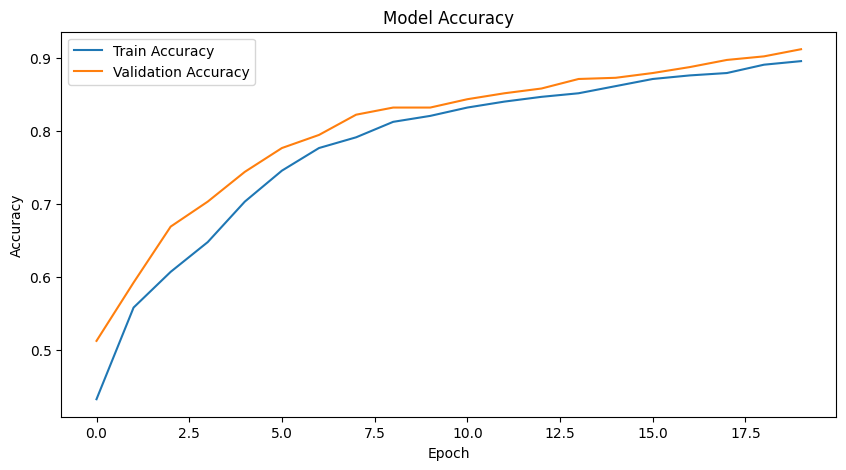

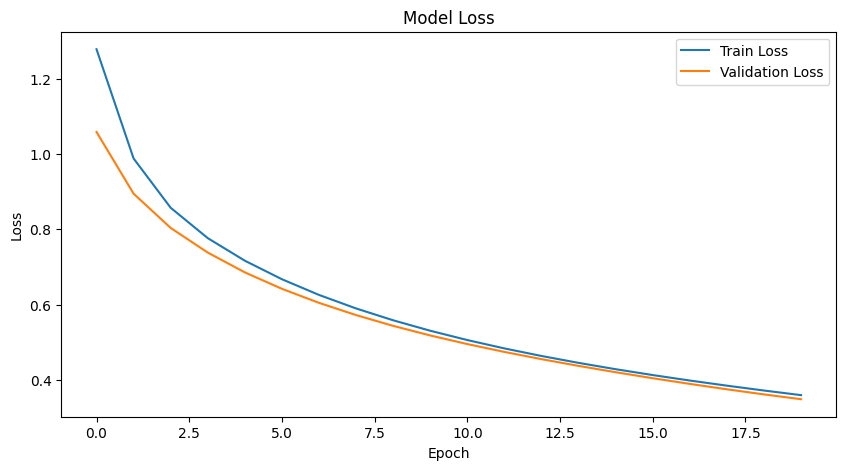

In [ ]:
import matplotlib.pyplot as plt

#Creating the Graph of Accuracy 

# Accuracy
plt.figure(figsize=(10,5))

plt.plot(
    history.history["accuracy"],
    label="Train Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.show()

#Creating the Graph of Loss 

# Loss
plt.figure(figsize=(10,5))

plt.plot(
    history.history["loss"],
    label="Train Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Model Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()

In [ ]:
# Predict Img Function
def predict_image(img_path):

    # Loading Image 
    img = image.load_img(
        img_path,
        target_size=(224,224)
    )

    
    img_array = image.img_to_array(
        img
    )

    img_array = np.expand_dims(
        img_array,
        axis=0
    )

    img_array = preprocess_input(
        img_array
    )

    prediction = model.predict(
        img_array
    )

    predicted_class = np.argmax(
        prediction
    )

    label = encoder.inverse_transform(
        [predicted_class]
    )[0]

    confidence = np.max(
        prediction
    )

    print(
        f"Prediction: {label}"
    )

    print(
        f"Confidence: {confidence:.2%}"
    )

    return label

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
Prediction: Stage IIIA Squamous Cell Carcinoma
Confidence: 47.73%


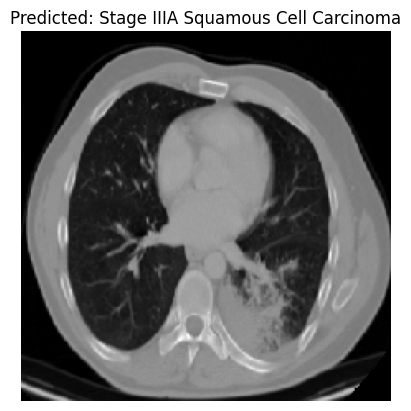

In [49]:
img_path = r"D:\Visual Studio Code\ML\LungCancerImg\Data\valid\squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa\000110 (6).png"

img = image.load_img(
    img_path,
    target_size=(224,224)
)

label = predict_image(img_path)

plt.imshow(img)
plt.title(f"Predicted: {label}")
plt.axis("off")
plt.show()

# Structure of Model

```text
    CSV
     ↓
Train DenseNet121
     ↓
Accuracy/Loss graph
     ↓
Save model
     ↓
Input new image
     ↓
Predict cancer type
     ↓
Display confidence
```


In [50]:
model.save("lung_cancer_classifier.keras")
print("Model saved successfully")

Model saved successfully


In [51]:
from tensorflow.keras.models import load_model

model = load_model("lung_cancer_classifier.keras")
print("Model loaded successfully")

Model loaded successfully


In [ ]:
img_path = r"D:\Visual Studio Code\ML\LungCancerImg\Data\valid\adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib\000108 (7).png"

label = predict_image(img_path)

print("Prediction:", label)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
Prediction: Stage IB Adenocarcinoma
Confidence: 75.45%
Stage IB Adenocarcinoma
